# Planner Comparison: BFS vs Greedy vs A*


Loads `results/summaries/*_runs.csv` and produces comparison charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import glob
import os

run_files = glob.glob('../results/summaries/*_runs.csv')
raw = pd.concat([pd.read_csv(f) for f in run_files], ignore_index=True)
print(f'Rows loaded: {len(raw)}  |  Algorithms: {sorted(raw["algorithm"].unique())}')
raw.head(3)

Rows loaded: 546  |  Algorithms: ['astar', 'bfs', 'greedy']


,source,group,env_version,map_name,difficulty,episode,algorithm,seed,solved,failure_reason,height,width,num_boxes,total_reward,steps,runtime_ms,nodes_expanded,deadlocks_pruned,dead_squares
0,custom,custom_core,custom_env,map_01,Easy-1box,0,astar,NaN,True,NaN,3.0,12.0,1.0,10.2,8,84.1799,4,0,1
1,custom,custom_core,custom_env,map_02,Medium-1box,0,astar,NaN,True,NaN,5.0,12.0,1.0,10.3,7,150.1439,4,8,22
2,custom,custom_core,custom_env,map_03,Medium-2box,0,astar,NaN,True,NaN,5.0,13.0,2.0,10.8,12,193.3000,20,6,6


In [2]:
# Deduplicate: steps and nodes_expanded are deterministic across repeated runs;
# runtime varies — take the median. Everything else: keep first occurrence.
KEY = ['algorithm', 'group', 'map_name']

runtime_med = raw.groupby(KEY)['runtime_ms'].median().reset_index(name='runtime_ms')
df = raw.groupby(KEY, as_index=False).first()
df['runtime_ms'] = runtime_med['runtime_ms'].values

# dqn_map_* were written under group=custom_additional; relabel for charts
df.loc[df['difficulty'] == 'DQN-3box', 'group'] = 'dqn_custom'

DIFFICULTY_ORDER = ['Easy-1box', 'Medium-1box', 'Large-1box', 'Medium-2box', 'Hard-3box', 'DQN-3box']
df['difficulty'] = pd.Categorical(df['difficulty'], categories=DIFFICULTY_ORDER, ordered=True)

print(f'Unique (algo, map) pairs after dedup: {len(df)}')
print('\nSolved count by group:')
print(df.groupby(['algorithm', 'group'])['solved'].agg(['sum', 'count']))

Unique (algo, map) pairs after dedup: 108

Solved count by group:
                             sum  count
algorithm group                        
astar     custom_additional    5      5
          custom_core         10     10
          dqn_custom           6      6
          original_v0          5      5
          original_v1          5      5
          original_v2          4      5
bfs       custom_additional    4      5
          custom_core         10     10
          dqn_custom           6      6
          original_v0          5      5
          original_v1          5      5
          original_v2          4      5
greedy    custom_additional    5      5
          custom_core         10     10
          dqn_custom           6      6
          original_v0          5      5
          original_v1          5      5
          original_v2          5      5


In [3]:
ALGOS  = ['bfs', 'greedy', 'astar']
COLORS = {'bfs': '#4C72B0', 'greedy': '#DD8452', 'astar': '#55A868'}
LABELS = {'bfs': 'BFS', 'greedy': 'Greedy', 'astar': 'A*'}
W = 0.28
os.makedirs('../results', exist_ok=True)

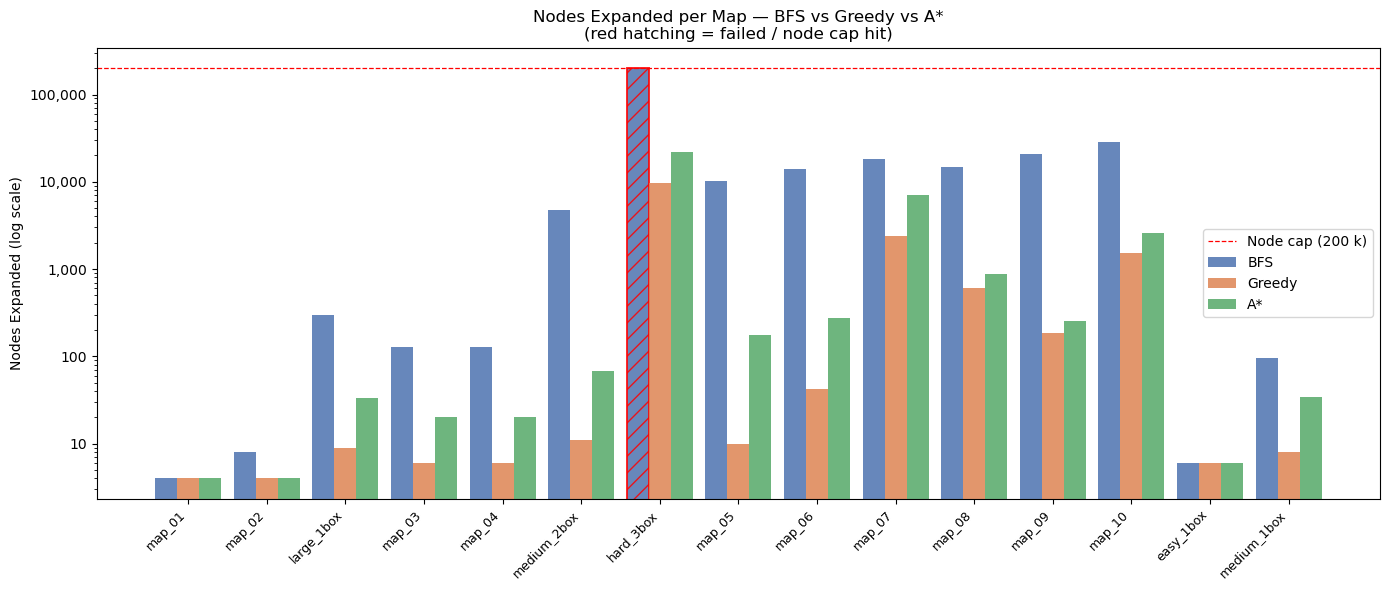

In [4]:
# Chart 1: Nodes Expanded per Map
# Shows A*'s heuristic advantage — dramatically fewer nodes than BFS on hard maps.
# Red hatching marks maps where the algorithm hit the 200 000 node cap and failed.

plot_maps = (
    df[df['group'].isin(['custom_core', 'custom_additional'])]
    .sort_values(['difficulty', 'map_name'])
    ['map_name'].unique()
)
x = np.arange(len(plot_maps))

fig, ax = plt.subplots(figsize=(14, 6))
for i, algo in enumerate(ALGOS):
    sub = df[df['algorithm'] == algo].set_index('map_name')
    nodes  = [sub.loc[m, 'nodes_expanded'] if m in sub.index else 0    for m in plot_maps]
    failed = [not sub.loc[m, 'solved']      if m in sub.index else True for m in plot_maps]
    bars = ax.bar(x + i * W, nodes, W, label=LABELS[algo], color=COLORS[algo], alpha=0.85)
    for bar, fail in zip(bars, failed):
        if fail:
            bar.set_hatch('//')
            bar.set_edgecolor('red')
            bar.set_linewidth(1.4)

ax.axhline(200_000, color='red', linestyle='--', linewidth=0.9, label='Node cap (200 k)')
ax.set_yscale('log')
ax.set_xticks(x + W)
ax.set_xticklabels(plot_maps, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Nodes Expanded (log scale)')
ax.set_title('Nodes Expanded per Map — BFS vs Greedy vs A*\n(red hatching = failed / node cap hit)')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.savefig('../results/fig_nodes_expanded.png', dpi=150, bbox_inches='tight')
plt.show()

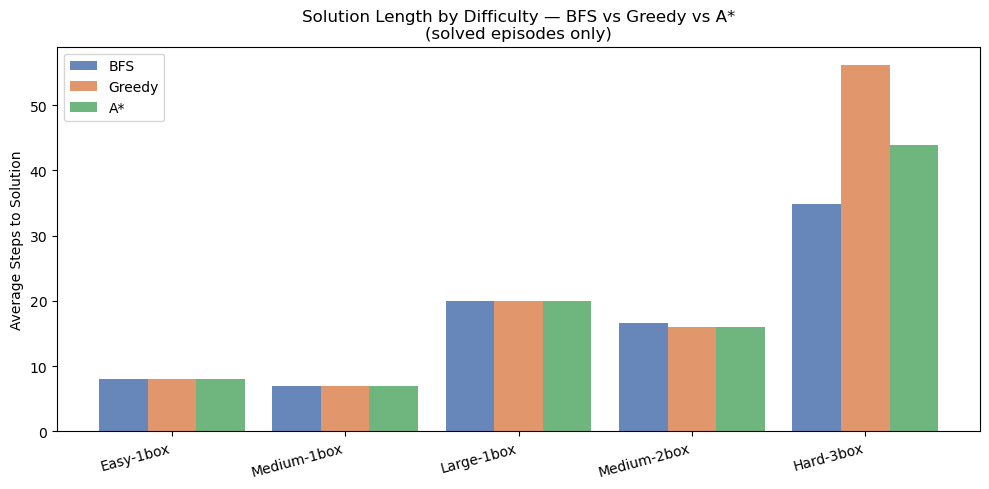

In [5]:
# Chart 2: Average Steps per Difficulty (solution quality)
# Among solved episodes only. A* finds push-optimal paths; Greedy uses far more moves.

custom_solved = df[df['group'].isin(['custom_core', 'custom_additional']) & df['solved']]
avg_steps = (
    custom_solved
    .groupby(['algorithm', 'difficulty'], observed=True)['steps']
    .mean().reset_index()
)
difficulties = [d for d in DIFFICULTY_ORDER if d in avg_steps['difficulty'].values]
x2 = np.arange(len(difficulties))

fig, ax = plt.subplots(figsize=(10, 5))
for i, algo in enumerate(ALGOS):
    sub = avg_steps[avg_steps['algorithm'] == algo].set_index('difficulty')
    vals = [sub.loc[d, 'steps'] if d in sub.index else 0 for d in difficulties]
    ax.bar(x2 + i * W, vals, W, label=LABELS[algo], color=COLORS[algo], alpha=0.85)

ax.set_xticks(x2 + W)
ax.set_xticklabels(difficulties, rotation=15, ha='right')
ax.set_ylabel('Average Steps to Solution')
ax.set_title('Solution Length by Difficulty — BFS vs Greedy vs A*\n(solved episodes only)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/fig_avg_steps.png', dpi=150, bbox_inches='tight')
plt.show()

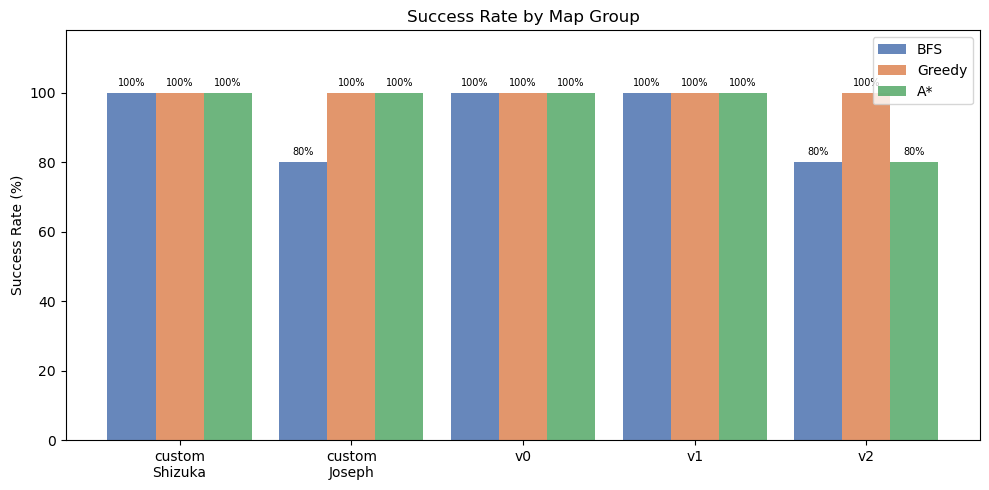

In [6]:
# Chart 3: Success Rate by Map Group
# BFS fails on the 15x15 hard_3box map. A* and Greedy solve everything in the custom sets.

GROUP_ORDER  = ['custom_core', 'custom_additional', 'original_v0', 'original_v1', 'original_v2']
GROUP_LABELS = {
    'custom_core':       'custom\nShizuka',
    'custom_additional': 'custom\nJoseph',
    'original_v0':       'v0',
    'original_v1':       'v1',
    'original_v2':       'v2',
}
groups_present = [g for g in GROUP_ORDER if g in df['group'].values]
x3 = np.arange(len(groups_present))

fig, ax = plt.subplots(figsize=(10, 5))
for i, algo in enumerate(ALGOS):
    sub = df[df['algorithm'] == algo].groupby('group')['solved'].mean()
    vals = [sub.get(g, np.nan) * 100 for g in groups_present]
    bars = ax.bar(x3 + i * W, vals, W, label=LABELS[algo], color=COLORS[algo], alpha=0.85)
    for bar, v in zip(bars, vals):
        if not np.isnan(v) and v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x3 + W)
ax.set_xticklabels([GROUP_LABELS.get(g, g) for g in groups_present])
ax.set_ylabel('Success Rate (%)')
ax.set_ylim(0, 118)
ax.set_title('Success Rate by Map Group')
ax.legend()
plt.tight_layout()
plt.savefig('../results/fig_success_rate.png', dpi=150, bbox_inches='tight')
plt.show()

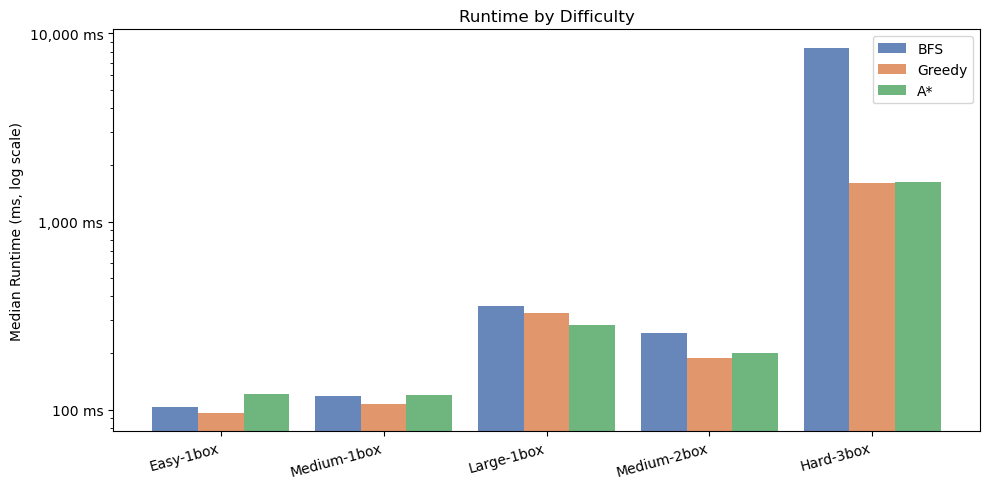

In [7]:
# Chart 4: Median Runtime by Difficulty (log scale)
# BFS runtime spikes on hard maps due to massive node expansion.

rt = (
    df[df['group'].isin(['custom_core', 'custom_additional'])]
    .groupby(['algorithm', 'difficulty'], observed=True)['runtime_ms']
    .median().reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for i, algo in enumerate(ALGOS):
    sub = rt[rt['algorithm'] == algo].set_index('difficulty')
    vals = [sub.loc[d, 'runtime_ms'] if d in sub.index else 0 for d in difficulties]
    ax.bar(x2 + i * W, vals, W, label=LABELS[algo], color=COLORS[algo], alpha=0.85)

ax.set_yscale('log')
ax.set_xticks(x2 + W)
ax.set_xticklabels(difficulties, rotation=15, ha='right')
ax.set_ylabel('Median Runtime (ms, log scale)')
ax.set_title('Runtime by Difficulty')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f} ms'))
plt.tight_layout()
plt.savefig('../results/fig_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Summary table
summary = (
    df[df['group'].isin(['custom_core', 'custom_additional'])]
    .groupby(['algorithm', 'difficulty'], observed=True)
    .agg(
        total    =('solved', 'count'),
        solved   =('solved', 'sum'),
        avg_steps=('steps', 'mean'),
        avg_nodes=('nodes_expanded', 'mean'),
        med_rt_ms=('runtime_ms', 'median'),
    )
    .round(1)
)
summary['success_%'] = (summary['solved'] / summary['total'] * 100).round(0).astype(int)
print(summary.to_string())

                       total  solved  avg_steps  avg_nodes  med_rt_ms  success_%
algorithm difficulty                                                            
astar     Easy-1box        1       1        8.0        4.0      121.1        100
          Medium-1box      1       1        7.0        4.0      120.0        100
          Large-1box       1       1       20.0       33.0      281.3        100
          Medium-2box      3       3       16.0       35.7      199.4        100
          Hard-3box        7       7       43.9     4694.4     1619.1        100
bfs       Easy-1box        1       1        8.0        4.0      103.0        100
          Medium-1box      1       1        7.0        8.0      117.8        100
          Large-1box       1       1       20.0      299.0      355.8        100
          Medium-2box      3       3       16.7     1677.3      255.9        100
          Hard-3box        7       6       47.0    43768.7     8410.0         86
greedy    Easy-1box        1